# Trabajo Práctico Integrador – Módulo II
## Machine Learning: del problema a la decisión

**Caso:** análisis de clientes de una empresa de servicios de telecomunicaciones.

**Objetivo:** analizar datos históricos de clientes para identificar patrones y construir modelos que permitan estudiar su comportamiento, estimar la facturación anual e identificar el riesgo de abandono.

En este trabajo vas a integrar modelos de **regresión**, **clasificación** y **clustering**. La meta no es solamente ejecutar algoritmos, sino justificar decisiones e interpretar resultados.


### Preguntas del caso
1. ¿Podemos estimar cuánto facturará un cliente durante el año?
2. ¿Podemos identificar clientes con riesgo de abandonar el servicio?
3. ¿Existen diferentes perfiles de clientes dentro de la base?

> **Entrega:** completar todas las celdas indicadas y escribir las respuestas en las celdas Markdown destinadas a interpretación.

**Fecha de Entrega:** 31 de agosto de 2026

## Archivos y variables

Archivo de trabajo: **`dataset_clientes_comunicaciones.csv`**

> Utilizá el archivo CSV provisto junto con este cuaderno.

Variables principales:

- `id_cliente`: identificador único del cliente.
- `edad`: edad en años.
- `antiguedad_meses`: cantidad de meses como cliente de la empresa.
- `cargo_mensual`: importe mensual facturado por los servicios contratados.
- `cantidad_servicios`: cantidad de servicios contratados.
- `consultas_soporte`: cantidad de consultas realizadas al área de soporte.
- `reclamos_ultimo_anio`: cantidad de reclamos registrados durante el último año.
- `horas_uso_mensual`: horas de utilización mensual de los servicios.
- `tipo_contrato`: Mensual, Anual o Bianual.
- `medio_pago`: medio de pago habitual.
- `satisfaccion`: puntaje de satisfacción del cliente, en una escala de 1 a 10, obtenido a partir de encuestas.
- `gasto_anual`: facturación total del cliente durante el último año. Variable objetivo sugerida para regresión.
- `abandono`: 0 = permanece; 1 = abandona. Variable objetivo para clasificación.

> Las variables representan información que la empresa podría obtener de sus sistemas de clientes, facturación, soporte y encuestas de satisfacción.

## 1. Importación de librerías

In [25]:
# Importá aquí las librerías necesarias.
# Sugerencia: pandas, numpy, matplotlib y herramientas de scikit-learn.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, silhouette_score)

# Pipeline: lo usamos en la sección 7 para encadenar StandardScaler + KNN
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Carga y exploración inicial

1. Cargá el CSV.
2. Mostrá las primeras filas.
3. Informá cantidad de filas y columnas.
4. Revisá tipos de datos.
5. Calculá estadísticas descriptivas.
6. Contá valores faltantes por variable.
7. Analizá la distribución de `abandono`.

In [26]:
# Cargá el dataset en un DataFrame llamado df
df = pd.read_csv('dataset_clientes_comunicaciones.csv')

In [27]:
# Primeras filas, shape, info y describe
display(df.head())
print(f'\nFilas: {df.shape[0]}  Columnas: {df.shape[1]}')
df.info()
df.describe().T.round(2)

,id_cliente,edad,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,tipo_contrato,medio_pago,satisfaccion,gasto_anual,abandono
0,C1001,30,23,57300,1,6,3,45.3,Anual,Tarjeta,2.7,568000,1
1,C1002,49,42,128000,4,1,1,78.1,Anual,Transferencia,7.9,1549000,0
2,C1003,52,89,120100,3,0,1,55.4,Bianual,Debito automatico,7.8,1513000,0
3,C1004,34,21,48600,1,4,1,37.0,Anual,Efectivo,3.9,632000,1
4,C1005,26,4,67600,3,1,0,37.5,Mensual,Tarjeta,4.6,926000,0



Filas: 1000  Columnas: 13
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            1000 non-null   str    
 1   edad                  1000 non-null   int64  
 2   antiguedad_meses      1000 non-null   int64  
 3   cargo_mensual         1000 non-null   int64  
 4   cantidad_servicios    1000 non-null   int64  
 5   consultas_soporte     1000 non-null   int64  
 6   reclamos_ultimo_anio  1000 non-null   int64  
 7   horas_uso_mensual     988 non-null    float64
 8   tipo_contrato         1000 non-null   str    
 9   medio_pago            990 non-null    str    
 10  satisfaccion          982 non-null    float64
 11  gasto_anual           1000 non-null   int64  
 12  abandono              1000 non-null   int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 101.7 KB


,count,mean,std,min,25%,50%,75%,max
edad,1000.0,37.68,11.97,18.0,28.00,37.0,47.00,70.0
antiguedad_meses,1000.0,38.51,28.06,1.0,14.00,35.0,60.00,117.0
cargo_mensual,1000.0,104002.30,32330.47,25000.0,77875.00,107200.0,129200.00,185000.0
cantidad_servicios,1000.0,2.92,1.30,1.0,2.00,3.0,4.00,6.0
consultas_soporte,1000.0,3.06,2.43,0.0,1.00,3.0,4.00,13.0
reclamos_ultimo_anio,1000.0,1.46,1.73,0.0,0.00,1.0,2.00,10.0
horas_uso_mensual,988.0,63.38,26.03,5.0,44.08,64.9,81.82,136.4
satisfaccion,982.0,6.68,1.97,1.0,5.30,7.0,8.10,10.0
gasto_anual,1000.0,1331074.00,412383.60,280000.0,1026000.00,1349500.0,1632250.00,2495000.0
abandono,1000.0,0.34,0.47,0.0,0.00,0.0,1.00,1.0


Valores faltantes por columna:
id_cliente               0
edad                     0
antiguedad_meses         0
cargo_mensual            0
cantidad_servicios       0
consultas_soporte        0
reclamos_ultimo_anio     0
horas_uso_mensual       12
tipo_contrato            0
medio_pago              10
satisfaccion            18
gasto_anual              0
abandono                 0
dtype: int64

Distribución de abandono:
abandono
0    660
1    340
Name: count, dtype: int64
abandono
0    66.0 %
1    34.0 %
Name: count, dtype: str


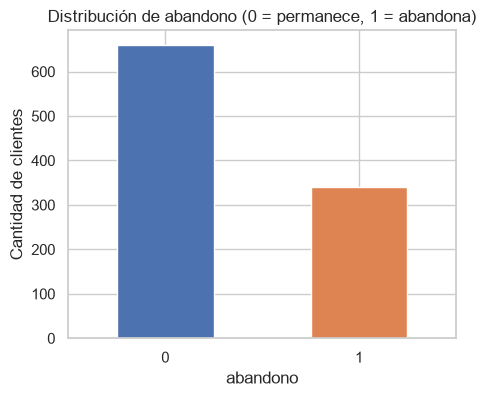

In [28]:
# Valores faltantes y distribución de abandono
print('Valores faltantes por columna:')
print(df.isnull().sum())

print('\nDistribución de abandono:')
conteo_abandono = df['abandono'].value_counts()
print(conteo_abandono)
print((conteo_abandono / len(df) * 100).round(1).astype(str) + ' %')

plt.figure(figsize=(5, 4))
conteo_abandono.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Distribución de abandono (0 = permanece, 1 = abandona)')
plt.xticks(rotation=0)
plt.ylabel('Cantidad de clientes')
plt.show()

### Interpretación 1
Respondé con tus palabras:

- ¿El dataset está completamente limpio?
- ¿Qué variables presentan valores faltantes?
- ¿La variable `abandono` está balanceada?
- ¿Por qué un desbalance puede afectar la interpretación del Accuracy?

**Respuesta:**

El dataset no está completamente limpio: tiene 1000 filas y 3 columnas con valores faltantes: `horas_uso_mensual` (12 nulos), `medio_pago` (10 nulos) y `satisfaccion` (18 nulos). El resto de las columnas no tiene nulos.

La variable `abandono` **no** está balanceada: 660 clientes permanecen (66 %) contra 340 que abandonan (34 %). No es un desbalance tan extremo como el 93 %/7 % típico de otros datasets de riesgo, pero igual conviene tenerlo en cuenta.

Un desbalance afecta al Accuracy porque esta métrica solo mide el porcentaje total de aciertos, sin distinguir en qué clase se equivoca el modelo. Con una proporción 66/34, un modelo que prediga "permanece" para *todos* los clientes ya acertaría el 66 % de las veces sin haber aprendido nada útil sobre quién realmente abandona. Por eso, para este problema, conviene mirar también Precision, Recall y F1 (especialmente el Recall de la clase `abandono=1`), y no solo el Accuracy.

## 3. Preparación de los datos

### 3.1 `id_cliente`
Explicá por qué `id_cliente` no debería utilizarse como predictor.

### 3.2 Valores faltantes
Elegí una estrategia razonable según el tipo de variable. Para los modelos se recomienda que la imputación se **ajuste solo con datos de entrenamiento**, para evitar fuga de información.

### Interpretación 2
- ¿Qué representa `id_cliente`?
- ¿Por qué no debe usarse como predictor?
- ¿Qué criterio usarías para imputar variables numéricas y categóricas?

**Respuesta:**

`id_cliente` es un identificador único (`C1001`, `C1002`, ...) que la empresa asigna administrativamente a cada cliente — no describe ninguna característica real de su comportamiento, contrato o uso del servicio.

No debe usarse como predictor porque no tiene relación causal ni estadística real con `gasto_anual` o `abandono`: es solo una etiqueta arbitraria. Si un modelo "aprendiera" algo a partir del ID, sería puro ruido o una coincidencia del orden en que se cargaron los clientes — no algo que vaya a generalizar a clientes nuevos (que tendrán un ID distinto y nunca antes visto).

Para imputar los valores faltantes:
- **Variables numéricas** (`horas_uso_mensual`, `satisfaccion`): mediana, calculada únicamente con los datos de entrenamiento. Se prefiere la mediana sobre la media porque es más robusta ante outliers.
- **Variables categóricas** (`medio_pago`): moda (el valor más frecuente), también calculada solo con entrenamiento.

En ambos casos, el valor de imputación se calcula **una sola vez sobre `X_train`** y se aplica igual a `X_train` y a `X_test` — si lo calculáramos usando también `X_test`, estaríamos filtrando información del conjunto de prueba hacia el entrenamiento (fuga de datos), lo mismo que se explica más abajo para el escalado del KNN.

# PARTE A — REGRESIÓN
## 4. ¿Cuánto facturará un cliente durante el año?

Variable objetivo: **`gasto_anual`**.

No uses `id_cliente` ni `abandono` como predictores.

### 4.1 Definir X e y y dividir entrenamiento/prueba
Usá `test_size=0.20` y `random_state=42`.

In [29]:
# Definí X_reg e y_reg y realizá train_test_split
predictoras = ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
               'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual',
               'tipo_contrato', 'medio_pago', 'satisfaccion']
num_cols = ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
            'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion']
cat_cols = ['tipo_contrato', 'medio_pago']

X_reg = df[predictoras]
y_reg = df['gasto_anual']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print('X_reg_train:', X_reg_train.shape)
print('X_reg_test :', X_reg_test.shape)

X_reg_train: (800, 10)
X_reg_test : (200, 10)


### 4.2 Preprocesamiento

- Variables numéricas: imputación por mediana.
- Variables categóricas: imputación por moda + One-Hot Encoding.

El enunciado sugiere usar `ColumnTransformer` y `Pipeline`. Lo resolvemos **a mano**, con
`fillna()` y `pd.get_dummies()`, que son las herramientas ya trabajadas en el módulo. El
requisito de fondo se cumple igual: la mediana y la moda se calculan **solo** con `X_train`
y después se aplican a `X_train` y `X_test`, y la codificación alinea las columnas de test
con `reindex()` para que ambos conjuntos tengan exactamente las mismas variables.

In [30]:
# Construí el preprocesamiento y el modelo de LinearRegression
#
# Preprocesamiento manual con pandas (fillna + get_dummies).
# Es el enfoque que usamos en los TPs anteriores del módulo: ColumnTransformer
# no aparece en ningún notebook previo del curso, así que resolvemos "a mano"
# con las mismas herramientas que ya veníamos usando.

def imputar_manual(X_train, X_test, num_cols, cat_cols):
    """Calcula mediana (numéricas) y moda (categóricas) SOLO con X_train,
    y aplica esos mismos valores a X_train y X_test."""
    X_train = X_train.copy()
    X_test = X_test.copy()
    valores = {}
    for c in num_cols:
        mediana = X_train[c].median()
        valores[c] = mediana
        X_train[c] = X_train[c].fillna(mediana)
        X_test[c] = X_test[c].fillna(mediana)
    for c in cat_cols:
        moda = X_train[c].mode()[0]
        valores[c] = moda
        X_train[c] = X_train[c].fillna(moda)
        X_test[c] = X_test[c].fillna(moda)
    return X_train, X_test, valores

def codificar_manual(X_train, X_test, cat_cols):
    """One-Hot Encoding con pd.get_dummies, alineando las columnas de
    X_test a las que resultaron en X_train (por si alguna categoría no
    aparece en uno de los dos conjuntos)."""
    X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)
    return X_train_dum, X_test_dum

X_reg_train_i, X_reg_test_i, valores_imputacion_reg = imputar_manual(X_reg_train, X_reg_test, num_cols, cat_cols)
X_reg_train_final, X_reg_test_final = codificar_manual(X_reg_train_i, X_reg_test_i, cat_cols)

print('Valores de imputación (calculados solo con train):', valores_imputacion_reg)
print('Columnas finales:', X_reg_train_final.columns.tolist())

modelo_reg = LinearRegression()
modelo_reg.fit(X_reg_train_final, y_reg_train)

Valores de imputación (calculados solo con train): {'edad': np.float64(37.0), 'antiguedad_meses': np.float64(34.0), 'cargo_mensual': np.float64(105800.0), 'cantidad_servicios': np.float64(3.0), 'consultas_soporte': np.float64(3.0), 'reclamos_ultimo_anio': np.float64(1.0), 'horas_uso_mensual': np.float64(64.4), 'satisfaccion': np.float64(7.0), 'tipo_contrato': 'Anual', 'medio_pago': 'Debito automatico'}
Columnas finales: ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios', 'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion', 'tipo_contrato_Bianual', 'tipo_contrato_Mensual', 'medio_pago_Efectivo', 'medio_pago_Tarjeta', 'medio_pago_Transferencia']


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 4.3 Entrenamiento y métricas
Calculá **MAE, MSE, RMSE y R²**.

In [31]:
# Entrená el modelo, predecí y calculá las métricas
y_reg_pred = modelo_reg.predict(X_reg_test_final)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = mse ** 0.5
r2 = modelo_reg.score(X_reg_test_final, y_reg_test)

print(f'MAE  : {mae:,.2f}')
print(f'MSE  : {mse:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')


MAE  : 72,478.79
MSE  : 8,549,179,138.68
RMSE : 92,461.77
R²   : 0.9504


### Interpretación 3
- ¿Qué representa el MAE en este problema?
- ¿Qué indica el RMSE?
- ¿Qué significa R²?
- ¿Considerás razonable el modelo? Justificá con las métricas.
- ¿Por qué Accuracy no corresponde para evaluar esta tarea?

**Respuesta:**

El **MAE** (72.479) significa que, en promedio, la predicción del modelo se aleja del `gasto_anual` real del cliente en aproximadamente $72.479. Está en la misma unidad que la variable objetivo (pesos/dólares de facturación), así que es fácil de leer directamente.

El **RMSE** (92.462) también está en esa misma unidad, pero al elevar los errores al cuadrado antes de promediar, penaliza más los errores grandes. Que el RMSE sea más alto que el MAE nos dice que hay algunos clientes donde el modelo se equivoca bastante más que el promedio (errores grandes puntuales), no que se equivoque de forma pareja en todos los casos.

El **R²** (0.9504) indica que el modelo explica aproximadamente el 95 % de la variabilidad del `gasto_anual` a partir de las variables predictoras. Es un valor alto.

Considerando que el `cargo_mensual` promedio de los clientes ronda los $100.000 (y `gasto_anual` es del orden de $1.000.000+ para muchos casos), un error promedio de ~$72.000 representa un porcentaje moderado del valor típico — el modelo es razonable, aunque no perfecto: para decisiones que dependan de una estimación muy precisa por cliente individual, ese margen de error debería tenerse en cuenta.

El Accuracy no corresponde acá porque es una métrica para **clasificación** (mide qué porcentaje de etiquetas categóricas se predijeron correctamente, un acierto binario "sí/no"). `gasto_anual` es una variable numérica continua: no tiene sentido preguntar si la predicción fue "correcta" o "incorrecta" en términos absolutos, sino **cuánto** se alejó del valor real — para eso existen MAE, MSE, RMSE y R².

# PARTE B — CLASIFICACIÓN
## 5. ¿Qué clientes podrían abandonar?

Variable objetivo: **`abandono`**.

No uses como predictores: `id_cliente`, `abandono` ni `gasto_anual`.

### 5.1 Data Leakage
Explicá por qué `gasto_anual` podría producir **fuga de información** si representa información conocida recién al finalizar el período que queremos predecir.

**Respuesta:**

`gasto_anual` es la facturación **total del año**, es decir, un dato que solo se termina de conocer cuando el año ya cerró — y el abandono, si ocurre, probablemente pasó *durante* ese año, no después. Un cliente que abandona a mitad de año probablemente tenga un `gasto_anual` mucho más bajo (dejó de facturar antes), simplemente **como consecuencia** de haber abandonado, no como una causa que lo explique de antemano.

Si usáramos `gasto_anual` como predictor de `abandono`, el modelo aprendería una relación que en la práctica no podríamos usar: en el momento real en que necesitamos predecir si un cliente va a abandonar (para poder actuar a tiempo, por ejemplo, ofreciéndole una promoción), todavía no sabemos cuál va a ser su `gasto_anual` final, porque eso depende justamente de si abandona o no. Sería usar información "del futuro" (posterior al momento de la predicción) para explicar el pasado — eso es **fuga de información (data leakage)**, y hace que las métricas del modelo se vean artificialmente mejores de lo que realmente serían en un caso de uso real.

### 5.2 Preparar datos
Usá `test_size=0.20`, `random_state=42` y `stratify=y`.

In [32]:
# Definí X_clf, y_clf y realizá train_test_split
X_clf = df[predictoras]
y_clf = df['abandono']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# Preprocesamiento manual, reutilizando las mismas funciones de la Parte A
X_clf_train_i, X_clf_test_i, valores_imputacion_clf = imputar_manual(X_clf_train, X_clf_test, num_cols, cat_cols)
X_clf_train_final, X_clf_test_final = codificar_manual(X_clf_train_i, X_clf_test_i, cat_cols)

print('X_clf_train:', X_clf_train_final.shape)
print('X_clf_test :', X_clf_test_final.shape)
print('Proporción de abandono en train:', y_clf_train.mean().round(3))
print('Proporción de abandono en test :', y_clf_test.mean().round(3))

X_clf_train: (800, 13)
X_clf_test : (200, 13)
Proporción de abandono en train: 0.34
Proporción de abandono en test : 0.34


## 6. Regresión Logística
Preprocesá los datos, entrená y calculá Accuracy, Precision, Recall, F1 y matriz de confusión.

Accuracy : 0.79
Precision: 0.6711
Recall   : 0.75
F1       : 0.7083

              precision    recall  f1-score   support

           0       0.86      0.81      0.84       132
           1       0.67      0.75      0.71        68

    accuracy                           0.79       200
   macro avg       0.77      0.78      0.77       200
weighted avg       0.80      0.79      0.79       200



c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


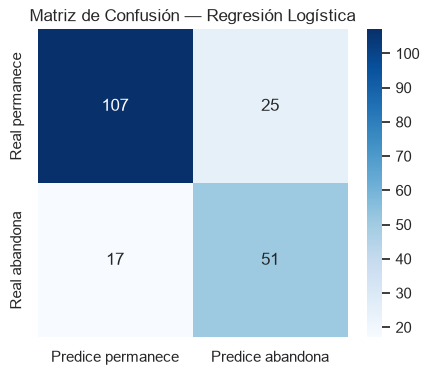

In [33]:
# Modelo de Regresión Logística

modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_clf_train_final, y_clf_train)

pred_log = modelo_log.predict(X_clf_test_final)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_log), 4))
print('Precision:', round(precision_score(y_clf_test, pred_log), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_log), 4))
print('F1       :', round(f1_score(y_clf_test, pred_log), 4))
print()
print(classification_report(y_clf_test, pred_log))

cm_log = confusion_matrix(y_clf_test, pred_log)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice permanece', 'Predice abandona'],
            yticklabels=['Real permanece', 'Real abandona'])
plt.title('Matriz de Confusión — Regresión Logística')
plt.show()

### Interpretación 4
- ¿Cuántos abandonos reales detectó correctamente?
- ¿Cuántos clientes que abandonaron fueron clasificados como permanencia?
- ¿Qué métrica refleja especialmente nuestra capacidad de detectar abandonos?

**Respuesta:**

Según la matriz de confusión del conjunto de prueba (68 clientes que realmente abandonaron, de un total de 200):

- El modelo detectó correctamente **51 abandonos reales** (verdaderos positivos).
- **17 clientes** que sí abandonaron fueron clasificados por error como "permanece" (falsos negativos) — son los casos más costosos para el negocio, porque son clientes en riesgo que el modelo no logró identificar.

La métrica que refleja específicamente esta capacidad es el **Recall** de la clase `abandono=1`: `51 / (51 + 17) = 0.75`. Es decir, el modelo logra detectar el 75 % de los clientes que realmente van a abandonar. El Accuracy general (0.79) no distingue este detalle, porque promedia los aciertos de ambas clases por igual.

## 7. KNN y escalado

KNN utiliza distancias, por eso las variables numéricas deben escalarse. El scaler debe ajustarse **solo con entrenamiento**.

Probá `k = 3, 5, 7, 9, 11`. Para evitar usar el conjunto de prueba para elegir `k`, podés separar una pequeña validación a partir del conjunto de entrenamiento.

In [34]:
# Prepará preprocesamiento con StandardScaler, probá distintos k y elegí uno
#
# Igual que en el TP de KNN (Unidad 5): encadenamos StandardScaler + KNeighborsClassifier
# en un Pipeline, y usamos GridSearchCV con validación cruzada (cv=5) para elegir k
# probando SOLO con X_clf_train_final — X_clf_test_final no participa en esta elección,
# así evitamos usar el conjunto de prueba para decidir el hiperparámetro.
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {'knn__n_neighbors': [3, 5, 7, 9, 11]}

grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_clf_train_final, y_clf_train)

resultados_k = pd.DataFrame(grid_knn.cv_results_)[['param_knn__n_neighbors', 'mean_test_score']]
print(resultados_k.to_string(index=False))
print()
print('Mejor k:', grid_knn.best_params_['knn__n_neighbors'])
print('Accuracy promedio (validación cruzada):', round(grid_knn.best_score_, 4))

 param_knn__n_neighbors  mean_test_score
                      3          0.80125
                      5          0.80250
                      7          0.78250
                      9          0.78000
                     11          0.79875

Mejor k: 5
Accuracy promedio (validación cruzada): 0.8025


Accuracy : 0.745
Precision: 0.6076
Recall   : 0.7059
F1       : 0.6531

              precision    recall  f1-score   support

           0       0.83      0.77      0.80       132
           1       0.61      0.71      0.65        68

    accuracy                           0.74       200
   macro avg       0.72      0.74      0.73       200
weighted avg       0.76      0.74      0.75       200



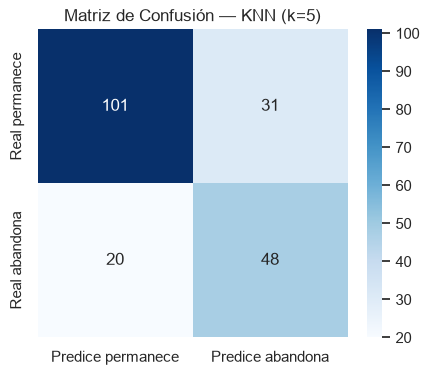

In [35]:
# Entrená el KNN final y calculá métricas + matriz de confusión
pred_knn = grid_knn.predict(X_clf_test_final)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_knn), 4))
print('Precision:', round(precision_score(y_clf_test, pred_knn), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_knn), 4))
print('F1       :', round(f1_score(y_clf_test, pred_knn), 4))
print()
print(classification_report(y_clf_test, pred_knn))

cm_knn = confusion_matrix(y_clf_test, pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice permanece', 'Predice abandona'],
            yticklabels=['Real permanece', 'Real abandona'])
plt.title(f"Matriz de Confusión — KNN (k={grid_knn.best_params_['knn__n_neighbors']})")
plt.show()

### Interpretación 5
- ¿Por qué el escalado es importante en KNN?
- ¿Por qué el scaler no debe ajustarse con todos los datos?
- ¿Qué valor de k elegiste y por qué?

**Respuesta:**

KNN clasifica un punto nuevo según sus vecinos más cercanos, y "cercano" se mide con una **distancia** (euclidiana) que combina todas las variables. Si no escalamos, una variable con números grandes como `cargo_mensual` (miles) dominaría completamente el cálculo de distancia frente a una variable como `satisfaccion` (escala 1 a 10), aunque ambas puedan ser igual de relevantes para predecir el abandono. Escalar (con `StandardScaler`, media 0 y desvío 1) hace que todas las variables pesen de forma comparable.

El *scaler* no debe ajustarse con todos los datos porque, si calculáramos la media y el desvío usando también `X_test`, el modelo estaría "viendo" información estadística del conjunto de prueba antes de tiempo — la misma fuga de información que se explicó para la imputación (Interpretación 2). Por eso el `StandardScaler` (dentro del `Pipeline`) se ajusta (`fit`) solo con `X_clf_train`, y luego simplemente se aplica (`transform`) a `X_clf_test`.

El valor de `k` elegido fue **k = 5**, el que dio mejor Accuracy promedio en la validación cruzada (`cv=5`) sobre el conjunto de entrenamiento, entre las opciones propuestas (3, 5, 7, 9, 11). Usamos validación cruzada — y no el propio `X_clf_test` — precisamente para no "espiar" el conjunto de prueba al momento de elegir el hiperparámetro.

## 8. Árbol de Decisión
Entrená un árbol base y luego probá controlar su complejidad con `max_depth`. Usá `random_state=42`.

Profundidad alcanzada sin límite: 17
Accuracy : 0.695
Precision: 0.5432
Recall   : 0.6471
F1       : 0.5906

              precision    recall  f1-score   support

           0       0.80      0.72      0.76       132
           1       0.54      0.65      0.59        68

    accuracy                           0.69       200
   macro avg       0.67      0.68      0.67       200
weighted avg       0.71      0.69      0.70       200



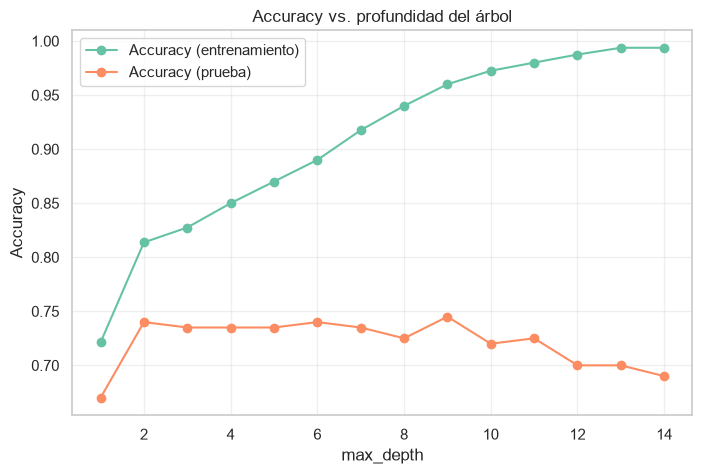

In [36]:
# Entrená y evaluá un DecisionTreeClassifier

# --- Árbol base, sin límite de profundidad ---
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_clf_train_final, y_clf_train)
pred_arbol = arbol.predict(X_clf_test_final)

print('Profundidad alcanzada sin límite:', arbol.get_depth())
print('Accuracy :', round(accuracy_score(y_clf_test, pred_arbol), 4))
print('Precision:', round(precision_score(y_clf_test, pred_arbol), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_arbol), 4))
print('F1       :', round(f1_score(y_clf_test, pred_arbol), 4))
print()
print(classification_report(y_clf_test, pred_arbol))

# --- Controlando la complejidad con max_depth ---
profundidades = range(1, 15)
acc_train_list, acc_test_list = [], []
for p in profundidades:
    a = DecisionTreeClassifier(max_depth=p, random_state=42)
    a.fit(X_clf_train_final, y_clf_train)
    acc_train_list.append(accuracy_score(y_clf_train, a.predict(X_clf_train_final)))
    acc_test_list.append(accuracy_score(y_clf_test, a.predict(X_clf_test_final)))

plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), acc_train_list, marker='o', label='Accuracy (entrenamiento)')
plt.plot(list(profundidades), acc_test_list, marker='o', label='Accuracy (prueba)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. profundidad del árbol')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Interpretación 6
- ¿Qué puede ocurrir si el árbol crece demasiado?
- Relacioná el resultado con **overfitting**.
- ¿Un árbol más complejo necesariamente generaliza mejor?

**Respuesta:**

Sin límite de profundidad, el árbol creció hasta 17 niveles y logró un Accuracy de apenas 0.695 en el conjunto de prueba — más bajo que la Regresión Logística (0.79) y que el KNN (0.745), a pesar de ser un modelo mucho más complejo. Esto es la firma clásica del **overfitting** (sobreajuste): el árbol, al no tener freno, sigue dividiendo los datos hasta memorizar particularidades del conjunto de entrenamiento (incluido su ruido), en vez de aprender el patrón general.

El gráfico de Accuracy vs. `max_depth` lo confirma: el Accuracy de **entrenamiento** sube de forma casi continua a medida que crece la profundidad (llega a rondar 0.99 en las profundidades más altas), mientras que el Accuracy de **prueba** mejora al principio, alcanza un máximo alrededor de `max_depth` 6-9 (≈0.74), y después empieza a **bajar** (hasta 0.69 en `max_depth`=14) aunque el modelo en entrenamiento siga "mejorando". Esa brecha creciente entre ambas curvas es exactamente overfitting: el árbol se vuelve mejor memorizando datos ya vistos, pero peor generalizando a datos nuevos.

Por lo tanto, **no**, un árbol más complejo no necesariamente generaliza mejor — de hecho, en este caso, generaliza peor. Lo que importa no es la profundidad máxima posible, sino encontrar el punto donde el modelo captura el patrón real sin empezar a ajustar el ruido particular del conjunto de entrenamiento (acá, más o menos `max_depth` entre 6 y 9).

## 9. Random Forest
Entrená un `RandomForestClassifier` con `n_estimators=100` y `random_state=42`.

Accuracy : 0.755
Precision: 0.6267
Recall   : 0.6912
F1       : 0.6573

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       132
           1       0.63      0.69      0.66        68

    accuracy                           0.76       200
   macro avg       0.73      0.74      0.73       200
weighted avg       0.76      0.76      0.76       200



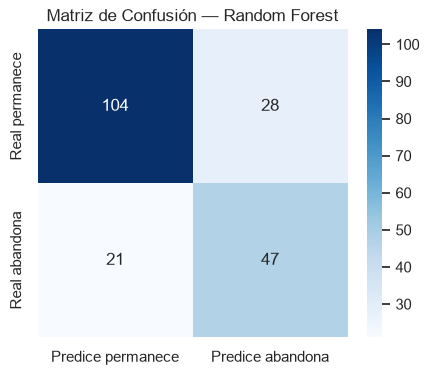

In [37]:
# Entrená y evaluá Random Forest
bosque = RandomForestClassifier(n_estimators=100, random_state=42)
bosque.fit(X_clf_train_final, y_clf_train)
pred_bosque = bosque.predict(X_clf_test_final)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_bosque), 4))
print('Precision:', round(precision_score(y_clf_test, pred_bosque), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_bosque), 4))
print('F1       :', round(f1_score(y_clf_test, pred_bosque), 4))
print()
print(classification_report(y_clf_test, pred_bosque))

cm_bosque = confusion_matrix(y_clf_test, pred_bosque)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bosque, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice permanece', 'Predice abandona'],
            yticklabels=['Real permanece', 'Real abandona'])
plt.title('Matriz de Confusión — Random Forest')
plt.show()

## 10. Comparación de modelos
Construí una tabla con Accuracy, Precision, Recall y F1 para los cuatro clasificadores.

In [38]:
# Armá un DataFrame comparativo con las métricas
comparacion = pd.DataFrame({
    'Regresión Logística': [accuracy_score(y_clf_test, pred_log), precision_score(y_clf_test, pred_log),
                             recall_score(y_clf_test, pred_log), f1_score(y_clf_test, pred_log)],
    'KNN':                 [accuracy_score(y_clf_test, pred_knn), precision_score(y_clf_test, pred_knn),
                             recall_score(y_clf_test, pred_knn), f1_score(y_clf_test, pred_knn)],
    'Árbol de Decisión':   [accuracy_score(y_clf_test, pred_arbol), precision_score(y_clf_test, pred_arbol),
                             recall_score(y_clf_test, pred_arbol), f1_score(y_clf_test, pred_arbol)],
    'Random Forest':       [accuracy_score(y_clf_test, pred_bosque), precision_score(y_clf_test, pred_bosque),
                             recall_score(y_clf_test, pred_bosque), f1_score(y_clf_test, pred_bosque)],
}, index=['Accuracy', 'Precision', 'Recall', 'F1']).T.round(4)

comparacion

,Accuracy,Precision,Recall,F1
Regresión Logística,0.790,0.6711,0.7500,0.7083
KNN,0.745,0.6076,0.7059,0.6531
Árbol de Decisión,0.695,0.5432,0.6471,0.5906
Random Forest,0.755,0.6267,0.6912,0.6573


### Interpretación 7
- ¿Qué modelo obtuvo mayor Accuracy?
- ¿Cuál obtuvo mayor Recall?
- ¿Cuál obtuvo mayor F1?
- ¿Todos los indicadores señalan al mismo modelo?
- Si la prioridad es detectar clientes que realmente abandonarán, ¿qué métrica priorizarías?
- ¿Qué modelo recomendarías? Justificá.

**Respuesta:**

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regresión Logística | **0.790** | **0.671** | **0.750** | **0.708** |
| KNN (k=5) | 0.745 | 0.608 | 0.706 | 0.653 |
| Árbol de Decisión | 0.695 | 0.543 | 0.647 | 0.591 |
| Random Forest | 0.755 | 0.627 | 0.691 | 0.657 |

La **Regresión Logística** obtuvo el mayor Accuracy, el mayor Recall y el mayor F1 — y de hecho también la mayor Precision. En este caso particular, **sí, todos los indicadores señalan al mismo modelo** (algo que no siempre ocurre, como advierte el material teórico de la Unidad 8: "la tabla no responde sola", pero acá la coincidencia entre métricas simplifica la decisión).

Si la prioridad es detectar clientes que realmente van a abandonar (para poder intervenir a tiempo, por ejemplo con una oferta de retención), la métrica a priorizar es el **Recall** de la clase `abandono=1`: mide qué proporción de los abandonos reales el modelo logra capturar. Un Recall alto es más importante que una Precision alta en este contexto, porque el costo de "no detectar" a un cliente que se va (falso negativo) suele ser mayor que el costo de contactar innecesariamente a alguien que en realidad iba a quedarse (falso positivo).

**Modelo recomendado: Regresión Logística.** No solo tiene el mejor desempeño en las cuatro métricas, sino que además es el modelo más simple e interpretable de los cuatro (sus coeficientes se pueden leer directamente), lo cual es una ventaja adicional para comunicar resultados a la empresa.

# PARTE C — APRENDIZAJE NO SUPERVISADO
## 11. Segmentación con K-Means

Usá estas variables:

`antiguedad_meses`, `cargo_mensual`, `cantidad_servicios`, `consultas_soporte`, `reclamos_ultimo_anio`, `horas_uso_mensual`, `satisfaccion`.

No uses `id_cliente`, `gasto_anual` ni `abandono`.

> Para esta segmentación se priorizan variables vinculadas con la relación del cliente con la empresa, el uso del servicio y su experiencia.

### 11.1 Preparación y escalado
Imputá faltantes y aplicá `StandardScaler`.

In [39]:
# Seleccioná variables, imputá y escalá
vars_cluster = ['antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
                'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion']

X_cluster = df[vars_cluster].copy()

# No hay separación train/test acá (no hay variable y), así que imputamos
# con la mediana calculada sobre todo el dataset de clustering.
for col in X_cluster.columns:
    if X_cluster[col].isnull().any():
        mediana = X_cluster[col].median()
        X_cluster[col] = X_cluster[col].fillna(mediana)
        print(f'{col}: imputados con mediana = {mediana}')

scaler_cluster = StandardScaler()
X_cluster_scaled = pd.DataFrame(
    scaler_cluster.fit_transform(X_cluster),
    columns=X_cluster.columns, index=X_cluster.index
)

X_cluster_scaled.describe().round(2)

horas_uso_mensual: imputados con mediana = 64.9
satisfaccion: imputados con mediana = 7.0


,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,satisfaccion
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.34,-2.44,-1.48,-1.26,-0.84,-2.26,-2.92
25%,-0.87,-0.81,-0.71,-0.85,-0.84,-0.72,-0.71
50%,-0.13,0.10,0.06,-0.03,-0.26,0.06,0.16
75%,0.77,0.78,0.83,0.39,0.32,0.71,0.72
max,2.80,2.51,2.37,4.09,4.95,2.82,1.70


### Interpretación 8
- ¿Por qué K-Means es sensible a la escala?
- ¿Qué ocurriría al comparar `cargo_mensual` con `satisfaccion` sin escalar?

**Respuesta:**

K-Means agrupa los puntos según su distancia euclidiana al centroide más cercano, y esa distancia se calcula sumando las diferencias al cuadrado de **todas** las variables juntas. Si las variables no están en la misma escala, las que tienen números más grandes dominan el cálculo, sin que eso signifique que sean más importantes — es un problema puramente numérico, no conceptual.

`cargo_mensual` toma valores del orden de decenas o cientos de miles, mientras que `satisfaccion` va de 1 a 10. Sin escalar, una diferencia de $10.000 en `cargo_mensual` pesaría muchísimo más en la distancia que una diferencia de 5 puntos en `satisfaccion` (que es, en términos relativos, una diferencia enorme dentro de su propia escala). El resultado sería que K-Means terminaría agrupando a los clientes **casi exclusivamente por `cargo_mensual`**, ignorando en la práctica la satisfacción, los reclamos o las consultas de soporte — variables que, para este análisis, nos interesa que pesen tanto como las demás. Por eso aplicamos `StandardScaler` antes de entrenar el modelo.

### 11.2 Método del codo y Silhouette Score
Probá valores de `k` entre 2 y 8. Graficá la inercia y calculá Silhouette Score.

In [40]:
# Calculá inercia y silhouette para k=2..8
k_range = range(2, 9)
inercias = []
siluetas = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_cluster_scaled, labels_k))

resultados_k_cluster = pd.DataFrame({'k': list(k_range), 'inercia': inercias, 'silhouette': siluetas}).round(3)
resultados_k_cluster

,k,inercia,silhouette
0,2,4003.894,0.385
1,3,2954.903,0.390
2,4,2635.359,0.272
3,5,2490.832,0.228
4,6,2374.782,0.184
5,7,2231.531,0.162
6,8,2148.567,0.158


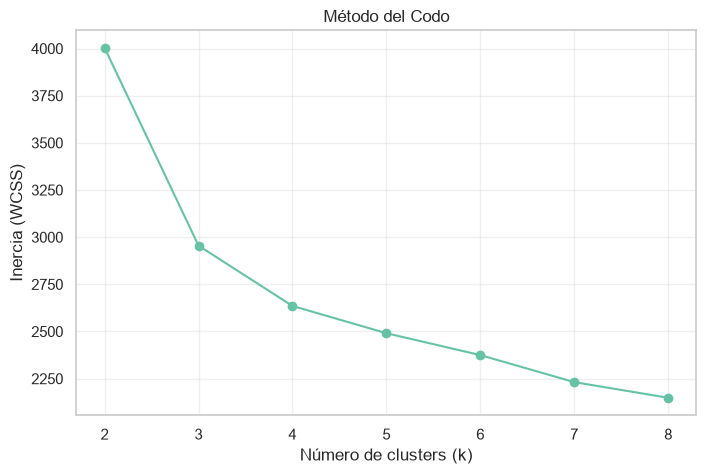

In [41]:
# Graficá el método del codo
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inercias, 'o-')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

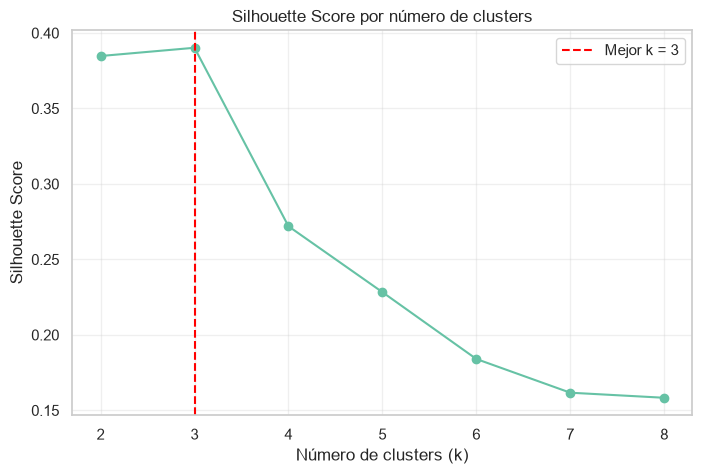

Mejor k según Silhouette: 3 (score=0.390)


In [42]:
# Graficá Silhouette Score
mejor_i = int(np.argmax(siluetas))
mejor_k = list(k_range)[mejor_i]

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), siluetas, 'o-')
plt.axvline(mejor_k, color='red', linestyle='--', label=f'Mejor k = {mejor_k}')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'Mejor k según Silhouette: {mejor_k} (score={siluetas[mejor_i]:.3f})')

### Interpretación 9
- ¿Qué valor de k presenta mayor Silhouette?
- ¿El método del codo y Silhouette necesariamente sugieren lo mismo?
- ¿Qué k elegirías finalmente? Justificá considerando métrica + interpretación.

**Respuesta:**

El mayor Silhouette Score se da en **k = 3** (0.390), apenas por encima de k = 2 (0.385) y bastante por encima del resto (k=4: 0.272, k=5: 0.228, y así decreciendo hasta k=8).

El método del codo y el Silhouette **no necesariamente coinciden** en general (el propio material teórico de la unidad lo advierte), aunque en este caso sí apuntan en la misma dirección: la inercia cae fuerte de k=2 a k=3 (de 4003.9 a 2954.9) y después la caída se vuelve mucho más gradual (2954.9 → 2635.4 → 2490.8 → ...), sin un quiebre tan marcado como el de k=2→3. Es decir, agregar un cuarto cluster ya no aporta una mejora tan significativa.

**k elegido: 3.** Combina el mejor Silhouette Score con un codo razonablemente visible en la inercia, y además da lugar a una cantidad de grupos manejable para interpretar y accionar desde el negocio (más adelante, con 3 clusters, cada uno tiene un perfil bastante diferenciable — ver Interpretación 10).

### 11.3 Modelo K-Means final e interpretación
Entrená K-Means con el k elegido. Agregá una columna `cluster` al DataFrame y calculá medias por cluster.

         antiguedad_meses  cargo_mensual  cantidad_servicios  \
cluster                                                        
0                   61.25      129169.45                3.82   
1                   24.86       95620.28                2.39   
2                   10.67       68379.12                1.81   

         consultas_soporte  reclamos_ultimo_anio  horas_uso_mensual  \
cluster                                                               
0                     1.80                  0.68              80.97   
1                     6.14                  4.03              62.45   
2                     2.96                  0.90              34.56   

         satisfaccion  
cluster                
0                7.95  
1                4.11  
2                6.39  

Cantidad de clientes por cluster:
cluster
0    491
1    212
2    297
Name: count, dtype: int64


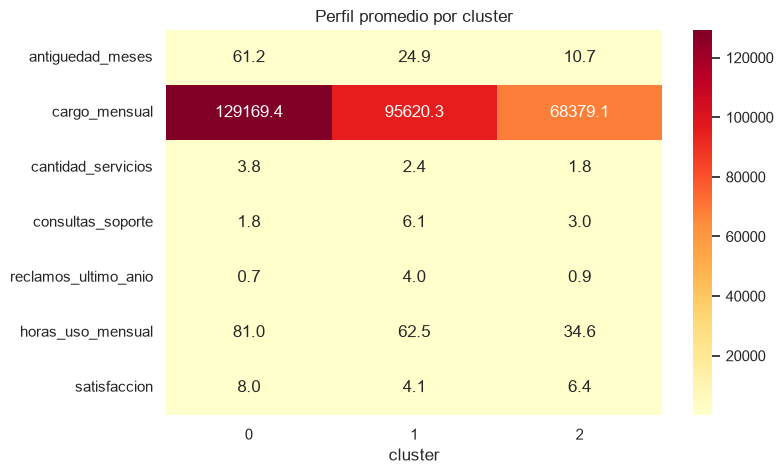

In [43]:
# Entrená KMeans final, agregá cluster y construí una tabla de perfiles
K_FINAL = 3
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
kmeans_final.fit(X_cluster_scaled)

df['cluster'] = kmeans_final.labels_

perfil_clusters = df.groupby('cluster')[vars_cluster].mean().round(2)
print(perfil_clusters)
print()
print('Cantidad de clientes por cluster:')
print(df['cluster'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.heatmap(perfil_clusters.T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Perfil promedio por cluster')
plt.show()

### Interpretación 10
Describí cada cluster con características concretas.

- ¿Cuál presenta mayor cantidad de reclamos?
- ¿Cuál tiene mayor satisfacción?
- ¿Cuál parece concentrar clientes más nuevos?
- ¿Los grupos tienen una interpretación razonable para el negocio?

**Respuesta:**

| Cluster | n | antigüedad | cargo | servicios | consultas | reclamos | horas | satisfacción | Perfil |
|---|---|---|---|---|---|---|---|---|---|
| 0 | 491 | 61.25 | 129.169 | 3.82 | 1.80 | 0.68 | 80.97 | 7.95 | **Leales de alto valor** |
| 1 | 212 | 24.86 | 95.620 | 2.39 | 6.14 | 4.03 | 62.45 | 4.11 | **En riesgo / problemáticos** |
| 2 | 297 | 10.67 | 68.379 | 1.81 | 2.96 | 0.90 | 34.56 | 6.39 | **Nuevos de plan básico** |

- **Mayor cantidad de reclamos**: el **cluster 1** (4.03 reclamos promedio), muy por encima de los otros dos.
- **Mayor satisfacción**: el **cluster 0** (7.95 sobre 10).
- **Clientes más nuevos**: el **cluster 2**, con antigüedad promedio de apenas 10.67 meses (contra 24.86 y 61.25 de los otros dos).

Los tres grupos tienen una interpretación razonable y accionable para el negocio:
- **Cluster 0 — Leales de alto valor**: clientes de muchos años, con más servicios contratados, muchas horas de uso y alta satisfacción, con pocos reclamos. Son la base más rentable y estable.
- **Cluster 1 — En riesgo**: clientes con antigüedad intermedia, pero con muchas consultas a soporte, muchos reclamos y la satisfacción más baja de los tres grupos. Es el segmento que más se acerca al perfil de un cliente que podría abandonar, y coincide con lo que encontramos en la Parte B: reclamos y consultas de soporte suelen asociarse a mayor riesgo de abandono.
- **Cluster 2 — Nuevos de plan básico**: clientes recientes, con menos servicios contratados y menos horas de uso, pero con una satisfacción razonable (6.39) y pocos reclamos — probablemente todavía están conociendo el servicio.

Esta segmentación le permitiría a la empresa, por ejemplo, diseñar campañas de fidelización distintas para el cluster 0, una intervención prioritaria de retención para el cluster 1, y estrategias de onboarding/upselling para el cluster 2.

# PARTE D — NUEVO CLIENTE

In [44]:
nuevo_cliente = {
    "edad": 34,
    "antiguedad_meses": 8,
    "cargo_mensual": 78000,
    "cantidad_servicios": 2,
    "consultas_soporte": 5,
    "reclamos_ultimo_anio": 3,
    "horas_uso_mensual": 65,
    "tipo_contrato": "Mensual",
    "medio_pago": "Tarjeta",
    "satisfaccion": 4
}

## 12. Usar los modelos

1. Estimá `gasto_anual` con Regresión Lineal.
2. Predecí `abandono` con el modelo de clasificación que recomendaste. Si es posible, obtené también la probabilidad.
3. Asigná el cliente a un cluster con el K-Means entrenado.

> En todos los casos, aplicá **exactamente el mismo preprocesamiento** utilizado durante el entrenamiento.

In [45]:
# Convertí nuevo_cliente a DataFrame y realizá las tres predicciones
nuevo_df = pd.DataFrame([nuevo_cliente])
nuevo_df

,edad,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,tipo_contrato,medio_pago,satisfaccion
0,34,8,78000,2,5,3,65,Mensual,Tarjeta,4


In [46]:
# 1. Estimar gasto_anual (Regresión Lineal) — aplicando el MISMO preprocesamiento que en la Parte A
nuevo_reg = nuevo_df[predictoras].copy()
for c in num_cols:
    nuevo_reg[c] = nuevo_reg[c].fillna(valores_imputacion_reg[c])
for c in cat_cols:
    nuevo_reg[c] = nuevo_reg[c].fillna(valores_imputacion_reg[c])
nuevo_reg_dum = pd.get_dummies(nuevo_reg, columns=cat_cols)
nuevo_reg_dum = nuevo_reg_dum.reindex(columns=X_reg_train_final.columns, fill_value=0)

gasto_estimado = modelo_reg.predict(nuevo_reg_dum)[0]
print(f'Gasto anual estimado: ${gasto_estimado:,.0f}')


Gasto anual estimado: $1,045,337


In [47]:
# 2. Predecir abandono con el modelo recomendado (Regresión Logística) + probabilidad
nuevo_clf = nuevo_df[predictoras].copy()
for c in num_cols:
    nuevo_clf[c] = nuevo_clf[c].fillna(valores_imputacion_clf[c])
for c in cat_cols:
    nuevo_clf[c] = nuevo_clf[c].fillna(valores_imputacion_clf[c])
nuevo_clf_dum = pd.get_dummies(nuevo_clf, columns=cat_cols)
nuevo_clf_dum = nuevo_clf_dum.reindex(columns=X_clf_train_final.columns, fill_value=0)

pred_abandono = modelo_log.predict(nuevo_clf_dum)[0]
proba_abandono = modelo_log.predict_proba(nuevo_clf_dum)[0]

print('Predicción:', 'ABANDONA' if pred_abandono == 1 else 'PERMANECE')
print(f'Probabilidad de permanecer: {proba_abandono[0]:.2%}')
print(f'Probabilidad de abandonar : {proba_abandono[1]:.2%}')

Predicción: ABANDONA
Probabilidad de permanecer: 9.44%
Probabilidad de abandonar : 90.56%


In [48]:
# 3. Asignar el cliente a un cluster con el K-Means entrenado
nuevo_cluster_input = nuevo_df[vars_cluster]
nuevo_cluster_scaled = scaler_cluster.transform(nuevo_cluster_input)
cluster_asignado = kmeans_final.predict(nuevo_cluster_scaled)[0]

print('Cluster asignado:', cluster_asignado)
print('\nPerfil promedio de ese cluster:')
print(perfil_clusters.loc[cluster_asignado])

Cluster asignado: 1

Perfil promedio de ese cluster:
antiguedad_meses           24.86
cargo_mensual           95620.28
cantidad_servicios          2.39
consultas_soporte           6.14
reclamos_ultimo_anio        4.03
horas_uso_mensual          62.45
satisfaccion                4.11
Name: 1, dtype: float64


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


### Interpretación 11
- ¿Cuál es el facturación anual estimada?
- ¿Se predice permanencia o abandono? ¿Con qué probabilidad, si corresponde?
- ¿A qué cluster pertenece?
- ¿La asignación al cluster es coherente con el perfil promedio del grupo?

**Respuesta:**

La facturación anual estimada para este cliente es de aproximadamente **$1.045.337**.

El modelo de Regresión Logística predice **ABANDONA**, con una probabilidad estimada de abandono del **90,6 %** (y 9,4 % de permanecer). Es una predicción con bastante seguridad, no un caso ambiguo cercano al 50 %.

El cliente fue asignado al **cluster 1** ("en riesgo / problemáticos" — ver Interpretación 10).

La asignación es totalmente coherente: este nuevo cliente tiene muy poca antigüedad (8 meses), varios reclamos en el último año (3) y varias consultas a soporte (5), y reportó una satisfacción baja (4 sobre 10) — es exactamente el patrón que caracteriza al cluster 1 (antigüedad intermedia-baja, muchos reclamos/consultas, satisfacción más baja de los tres grupos). Que tanto el modelo de clasificación (probabilidad de abandono alta) como el clustering (asignado al grupo de mayor riesgo), entrenados de forma completamente independiente, coincidan en la misma conclusión sobre este cliente, refuerza la confianza en el diagnóstico: es un cliente con perfil de riesgo real, no un caso límite dudoso.

# PARTE E — REFLEXIÓN FINAL

## 13. Integración conceptual
Respondé con tus palabras:

1. ¿Cuál es la diferencia entre regresión, clasificación y clustering?
2. ¿Por qué no utilizamos las mismas métricas en los tres problemas?
3. ¿Un Accuracy alto garantiza buenas predicciones en todos los casos?
4. ¿Qué función cumple el conjunto de prueba?
5. ¿Existe un algoritmo que sea siempre mejor que los demás?
6. ¿Por qué interpretar los resultados es tan importante como ejecutar `.fit()` y `.predict()`?

**Respuesta:**

**1. Regresión vs. clasificación vs. clustering.** Los tres son formas de Machine Learning, pero resuelven preguntas distintas. La regresión predice un **número continuo** (acá, `gasto_anual`). La clasificación predice una **categoría** entre un conjunto conocido de antemano (acá, `abandono`: 0 o 1). El clustering no predice nada que ya conozcamos: **descubre grupos** dentro de los datos sin que existan etiquetas previas (acá, los 3 perfiles de clientes) — regresión y clasificación son aprendizaje supervisado (hay un `y` real para comparar), clustering es no supervisado (no lo hay).

**2. Por qué cambian las métricas.** Las métricas tienen que ser coherentes con el tipo de salida del modelo. MAE/MSE/RMSE/R² miden **distancia numérica** entre una predicción y un valor real, así que solo tienen sentido en regresión. Accuracy/Precision/Recall/F1 miden **aciertos y errores entre categorías**, así que solo aplican en clasificación. Silhouette/Inercia miden **qué tan compactos y separados** quedan los grupos, porque en clustering no hay una "respuesta correcta" contra la cual comparar.

**3. ¿Accuracy alto = buenas predicciones siempre?** No. Con clases desbalanceadas (como vimos en la Interpretación 1, 66 %/34 %), un Accuracy alto puede esconder que el modelo casi no detecta la clase minoritaria. Por eso conviene mirar siempre Precision, Recall y F1 además del Accuracy, sobre todo cuando el error en una clase (por ejemplo, no detectar un abandono) es más costoso que en la otra.

**4. Función del conjunto de prueba.** Sirve para medir qué tan bien generaliza el modelo a datos que **nunca vio** durante el entrenamiento. Si evaluáramos con los mismos datos usados para entrenar, no podríamos distinguir si el modelo aprendió un patrón real o simplemente memorizó los ejemplos (overfitting, como vimos con el árbol de decisión sin límite de profundidad).

**5. ¿Un algoritmo siempre mejor que los demás?** No existe tal cosa (a veces llamado el principio de "no hay almuerzo gratis" en Machine Learning). En este mismo TP, la Regresión Logística ganó en clasificación, pero eso depende del dataset: en otro problema, con relaciones más no lineales o con más variables irrelevantes, un Random Forest o un árbol podrían funcionar mejor. Por eso conviene comparar varios modelos en cada problema concreto, en vez de asumir que uno es "el mejor" en general.

**6. Por qué interpretar es tan importante como `.fit()`/`.predict()`.** Ejecutar el código y obtener una métrica es solo el primer paso: una métrica sola (por ejemplo, "R²=0.95" o "Accuracy=0.79") no le dice nada útil a alguien que no sabe qué significa ese número, ni si es suficiente para el problema, ni qué errores comete el modelo, ni qué limitaciones tiene. Interpretar es lo que transforma un resultado técnico en una conclusión que realmente sirve para tomar una decisión de negocio — y es, además, lo que permite detectar cuándo un modelo, a pesar de tener buenas métricas, no debería usarse para decidir en automático (como el caso de este TP, donde recomendamos que las predicciones apoyen decisiones, pero no las reemplacen).

# 14. Comunicación de Resultados

Escribí entre **200 y 300 palabras** como si tuvieras que presentar el trabajo a una persona que no conoce Machine Learning.

La conclusión debe explicar:

- si fue posible estimar razonablemente la facturación anual;
- si fue posible identificar clientes con riesgo de abandono;
- qué modelo de clasificación recomendarías;
- qué perfiles aparecieron mediante K-Means;
- qué características presenta el nuevo cliente;
- qué limitaciones tienen los resultados.

**Conclusión:**

Analizamos los datos históricos de 1000 clientes de la empresa para responder tres preguntas de negocio.

Primero, sí fue posible estimar razonablemente cuánto facturará un cliente en el año: el modelo de regresión explica un 95 % de la variación en la facturación anual, con un margen de error promedio de unos $72.000 — útil como estimación general, aunque no exacto para cada caso individual.

Segundo, también fue posible identificar clientes con riesgo de abandono. Evaluamos cuatro modelos de clasificación (Regresión Logística, KNN, Árbol de Decisión y Random Forest), y la **Regresión Logística** obtuvo el mejor resultado en las cuatro métricas evaluadas, detectando 3 de cada 4 clientes que efectivamente abandonan. Es el modelo que recomendamos, tanto por su desempeño como por ser el más fácil de explicar.

Tercero, mediante K-Means encontramos **tres perfiles de clientes** bien diferenciados: clientes leales de alto valor (antiguos, satisfechos, con pocos reclamos), clientes en riesgo (muchos reclamos y consultas, baja satisfacción) y clientes nuevos con planes básicos.

Aplicamos los tres modelos a un cliente nuevo hipotético: se le estimó una facturación anual de ~$1.045.000, el modelo de clasificación predijo que **abandonará** con un 90 % de probabilidad, y el clustering lo ubicó en el grupo "en riesgo" — las tres herramientas coincidieron en la misma lectura de este cliente.

Como limitación importante: estos resultados corresponden a los datos analizados en un momento puntual, y ningún modelo acierta siempre — el de clasificación, por ejemplo, todavía no detecta 1 de cada 4 abandonos reales. Las predicciones deberían usarse como apoyo para decidir a qué clientes prestarles atención, no como una decisión automática y definitiva.